In [1]:
import os
data_dir = os.getcwd()


In [2]:
import numpy as np

In [3]:
fes2d_args = dict(
      cmap="coolwarm",
      bins=18,
      n_contours=5,
      contour_lines=True,
      alpha_lines=0.35,
      alpha_contours=0.6,
      #mask_thresh=2,
      mask=False,
      scatter=True,
      scatter_alpha = 0,
      scatter_size=.5,
      scatter_stride=1,
      scatter_max=.35,
      scatter_min=.15,
      scatter_cmap="coolwarm",
      # hide_ax=False,
      extend_border=0.,
    )

In [4]:
import matplotlib.pyplot as plt

In [5]:
elvim_dir = '/Users/kaushikborthakur1211/Desktop/Berlin_collab/elvim_data/'
weights_disp = np.loadtxt(elvim_dir+'weights_disp.dat')
weights_disp = weights_disp[::10]
weights_c22 = np.loadtxt(elvim_dir+'weights_c22.dat')
weights_c22 = weights_c22[::10]
weights_c36m = np.loadtxt(elvim_dir+'weights_c36m.dat')
weights_c36m = weights_c36m[::10]

In [6]:
rg_disp = np.loadtxt(elvim_dir+'Rg_disp.dat')
rg_disp = rg_disp[::10]
rg_c22 = np.loadtxt(elvim_dir+'Rg_c22.dat')
rg_c22 = rg_c22[::10]
rg_c36m = np.loadtxt(elvim_dir+'Rg_c36m.dat')
rg_c36m = rg_c36m[::10]

In [7]:
sa_disp = np.loadtxt(elvim_dir+'Sa_disp.dat')
sa_disp = sa_disp[::10]
sa_c22 = np.loadtxt(elvim_dir+'Sa_c22.dat')
sa_c22 = sa_c22[::10]
sa_c36m = np.loadtxt(elvim_dir+'Sa_c36m.dat')
sa_c36m = sa_c36m[::10]


In [8]:
lengths = np.array([3000, len(sa_disp), len(sa_c22), len(sa_c36m)])

In [9]:
sa_cg = np.loadtxt(elvim_dir+'Sa_CG.dat')
rg_cg = np.loadtxt(elvim_dir+'Rg_CG.dat')
weights_cg = np.loadtxt(elvim_dir+'weights_CG.dat')

In [10]:
elvim = np.loadtxt(elvim_dir+'combined.elvim.dat')
elvims = np.array_split(elvim,indices_or_sections = np.cumsum(lengths)[:-1])

ELViM projection on Rg, Sa latent space

[writhe_tools] ⏭️ Skipping 'graph_utils' (missing: torch_geometric)
[writhe_tools] 👉 To enable this module, install: pip install writhe-tools[graph]


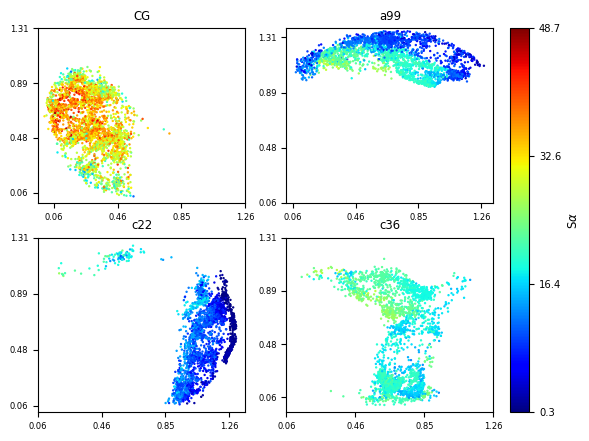

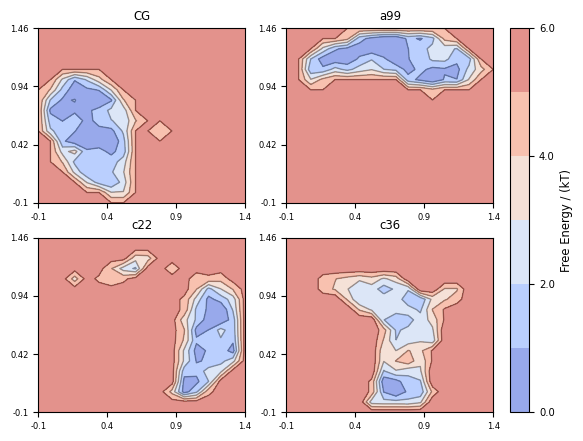

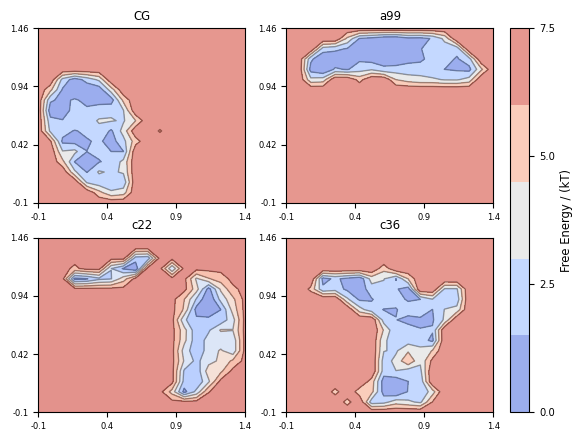

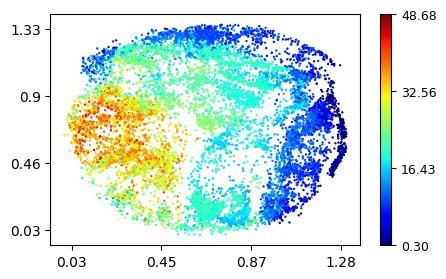

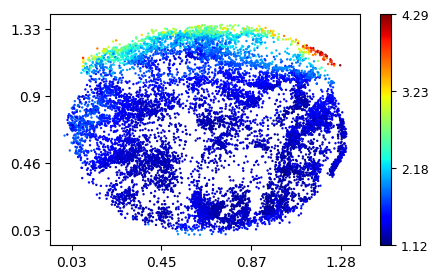

In [11]:
from writhe_tools.plots import subplots_proj2d, proj2d, subplots_fes2d
labels = ['CG', 'a99', 'c22', 'c36']

from writhe_tools.plots import get_extrema
extent = [get_extrema(i, .1) for i in elvim.T]

subplots_proj2d(elvims,[sa_cg, sa_disp, sa_c22, sa_c36m] , 2, 2, dscrs=labels, figsize=(6, 6), cbar_label=r'S$\alpha$')
subplots_fes2d(elvims , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True,**fes2d_args)
subplots_fes2d(elvims , 2, 2, dscrs=labels, figsize=(6, 6),extent=extent, share_extent=True, weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m], **fes2d_args)
proj2d(elvim, np.concatenate([sa_cg, sa_disp, sa_c22, sa_c36m]))
proj2d(elvim, np.concatenate([rg_cg, rg_disp, rg_c22, rg_c36m]))

Unweighted and Weighted Similarity Metrics for the 4 systems

/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1003: UserWarning: Bins to use in densitiy estimators has already been set to 80. Changing to 20. Consider recomputing all densities
  warnings.warn(
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((


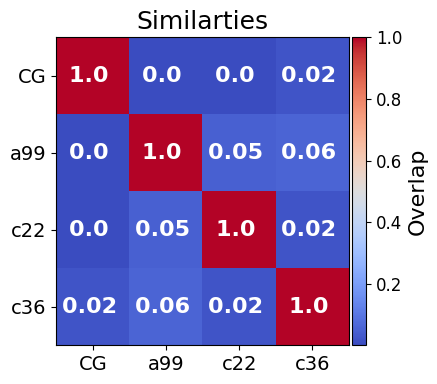

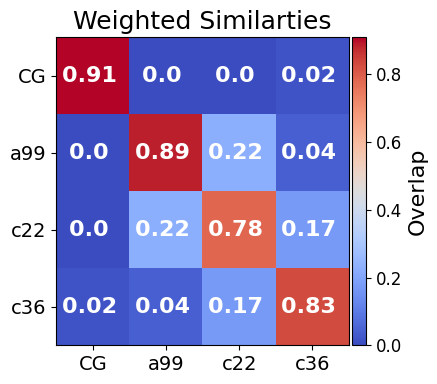

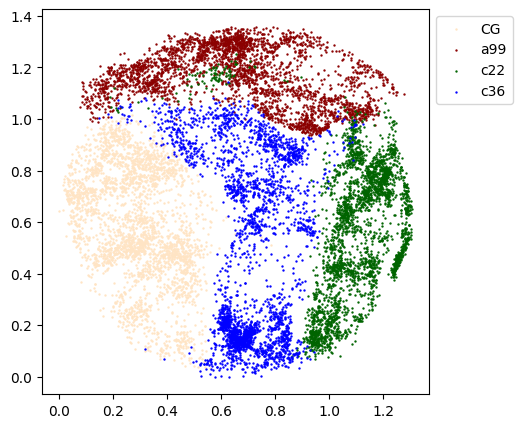

In [49]:
from writhe_tools.stats import DensityComparator
from writhe_tools.plots import annotated_matrix_plot


comp = DensityComparator(elvims, weights=[weights_cg, weights_disp, weights_c22, weights_c36m])
comp.estimate_kde()
comp.estimate_kde(weight=True)
comp.estimate_hist(bins=20)
comp.estimate_hist(bins=20, weight=True)
mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
#mat[i, j] = comp.compare('hists')
mat[i, j] = comp.compare('kdes')
mat += mat.T
mat[np.diag_indices(4)] = np.ones(4)
annotated_matrix_plot(mat, tick_labels=labels, title='Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )

mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists', weight=True)
mat += mat.T
mat[np.diag_indices(4)] = np.array([comp.compare("kdes", pairs = np.array([[i, i]]), weight0=False, weight1=True) for i in range(4)]).flatten()

annotated_matrix_plot(mat, tick_labels=labels, title='Weighted Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )


fig, axes  = plt.subplots(1,1,figsize=(5, 5))
for color, label,  x in zip(['bisque', 'darkred', 'darkgreen', 'blue'], labels, elvims):
    axes.scatter(*x[:, :2].T, c=color, label=label, s=0.5)
axes.legend(bbox_to_anchor=[1,1], )

In [50]:
import mdtraj as md
pdb= 'structure.pdb'
top = md.load(pdb).top

In [51]:
from writhe_tools.utils import lsdir, reindex_list
from writhe_tools.md_tools import ResidueDistances
import mdtraj as md
files = reindex_list(lsdir(".", keyword = ['xtc'], exclude=['combined', 'out', 'maker'], match=all), [2, -1, 0, 1])
pdb = './structure.pdb'
distances = [ResidueDistances(index_0=np.arange(71), traj=md.load(file, top=pdb, atom_indices=top.select('name CA'))) for file in files]


/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/utils/sorting.py:79: UserWarning: Not all strings contain a number, returning unsorted input list to avoid throwing an error. If you want to only consider strings that contain a digit, set indexed to True 
  warnings.warn("Not all strings contain a number, returning unsorted input list to avoid throwing an error. "


In [52]:
from importlib import reload
import writhe_tools
reload(writhe_tools)
reload(writhe_tools.plots)
from writhe_tools.plots import subplots_fes2d, subplots_proj2d

PCA on distant features for the combined trajectories

/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1003: UserWarning: Bins to use in densitiy estimators has already been set to 80. Changing to 20. Consider recomputing all densities
  warnings.warn(
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((


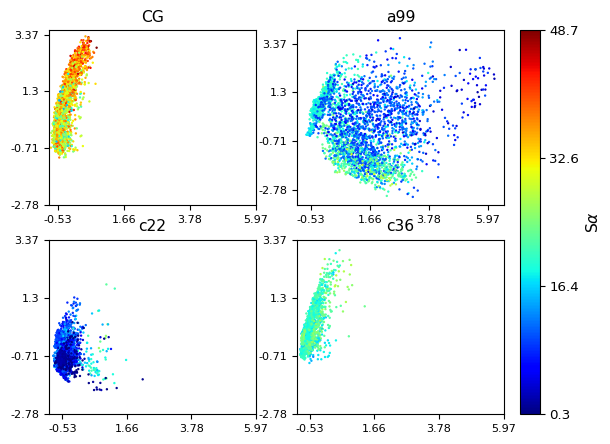

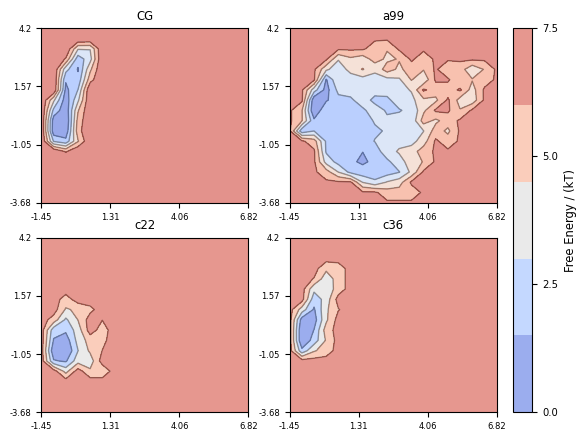

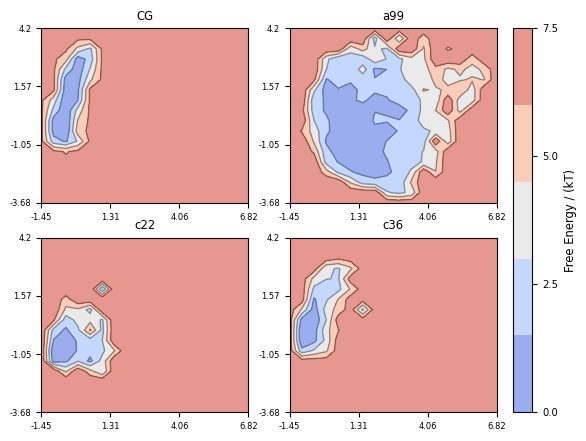

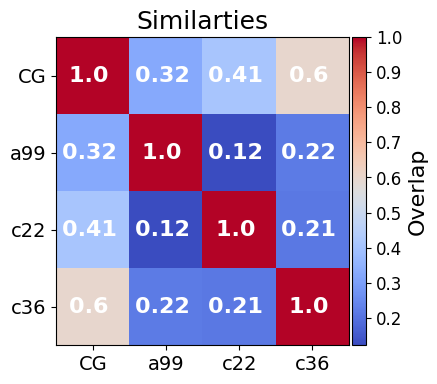

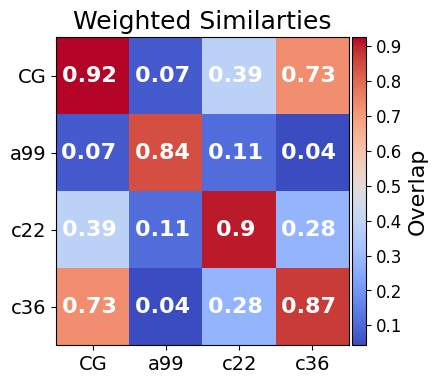

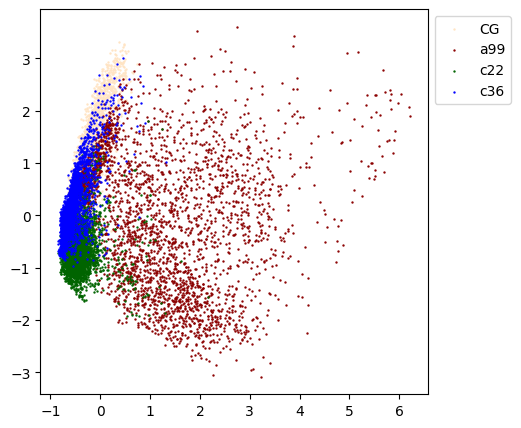

In [53]:
from writhe_tools.stats import pca
lengths = [len(i.distances) for i in distances]
cat = np.concatenate([i.distances for i in distances], axis=0)
mu = cat.mean(0)
proj, s, v = pca(cat, scale_projection=True)

from writhe_tools.plots import get_extrema
extent = [get_extrema(i, .6) for i in proj[:, :2].T]

all_projs = [i[:, :2] for i in np.array_split(proj, np.cumsum(lengths)[:-1])]
subplots_proj2d(all_projs,[sa_cg, sa_disp, sa_c22, sa_c36m] , 2, 2, dscrs=labels, figsize=(6, 6), font_scale=0.8, 
                cbar_label=r'S$\alpha$')
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True, **fes2d_args)
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True,
               weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m], **fes2d_args)




comp = DensityComparator(all_projs, weights=[weights_cg, weights_disp, weights_c22, weights_c36m])
comp.estimate_kde()
comp.estimate_kde(weight=True)
comp.estimate_hist(bins=20)
comp.estimate_hist(bins=20, weight=True)
mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
#mat[i, j] = comp.compare('hists')
mat[i, j] = comp.compare('kdes')
mat += mat.T
mat[np.diag_indices(4)] = np.ones(4)
annotated_matrix_plot(mat, tick_labels=labels, title='Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )

mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists', weight=True)
mat += mat.T
mat[np.diag_indices(4)] = np.array([comp.compare("kdes", pairs = np.array([[i, i]]), weight0=False, weight1=True) for i in range(4)]).flatten()

annotated_matrix_plot(mat, tick_labels=labels, title='Weighted Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )


fig, axes  = plt.subplots(1,1,figsize=(5, 5))
for color, label,  x in zip(['bisque', 'darkred', 'darkgreen', 'blue'], labels, all_projs):
    axes.scatter(*x[:, :2].T, c=color, label=label, s=0.5)
axes.legend(bbox_to_anchor=[1,1], )

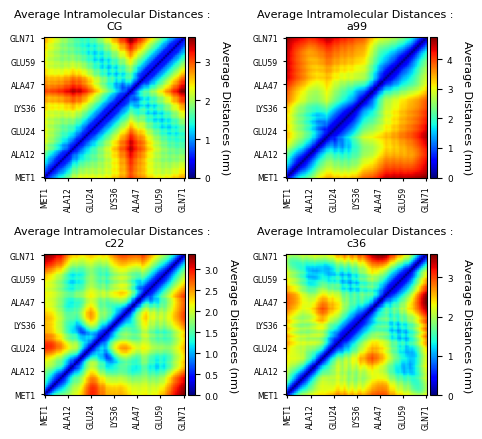

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(5, 4.5))
for ax, obj, label in zip(axes.flat, distances, labels):
    obj.plot(ax=ax, xticks_rotation=90, label_stride=10, dscr=f'\n{label}', font_scale=.8)
    
fig.tight_layout()

In [55]:
from writhe_tools.md_tools import to_distance_matrix

Projection of CGML ensemble onto the latent space of the 3 MD ensembles 

/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1003: UserWarning: Bins to use in densitiy estimators has already been set to 80. Changing to 20. Consider recomputing all densities
  warnings.warn(
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((


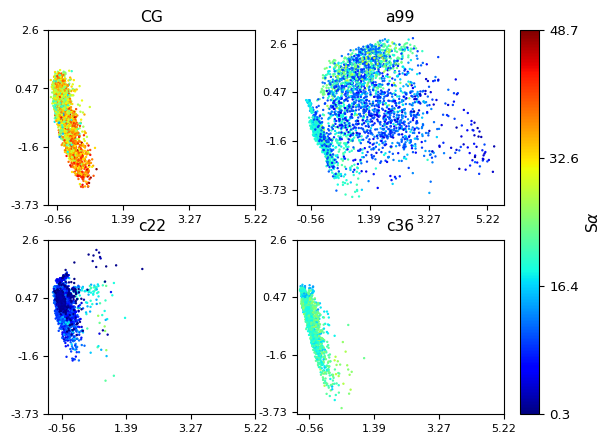

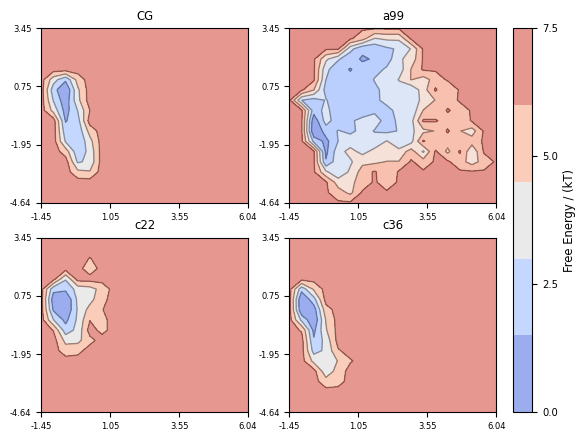

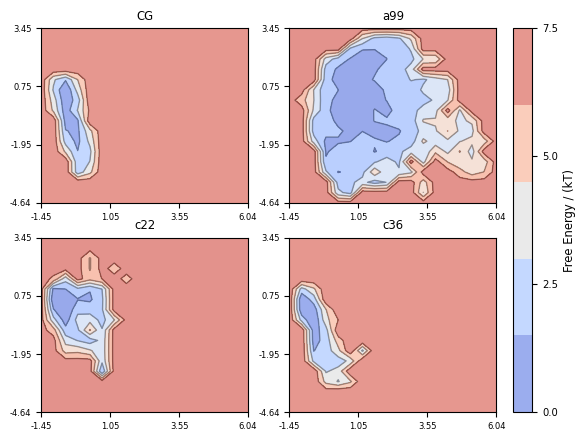

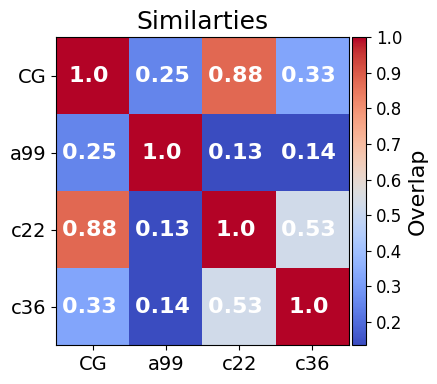

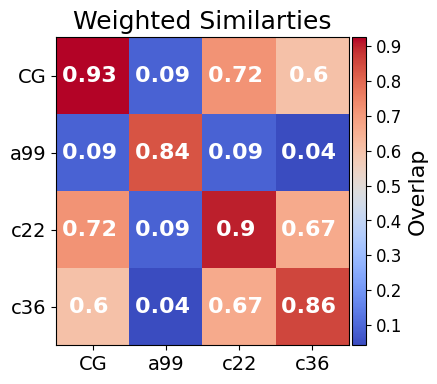

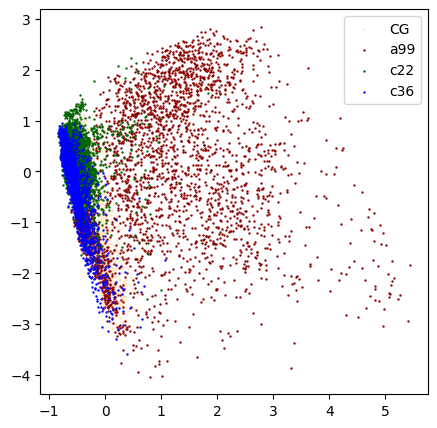

In [56]:
from writhe_tools.stats import pca
lengths = [len(i.distances) for i in distances]
cat = np.concatenate([i.distances for i in distances[1:]], axis=0)
mu = cat.mean(0)
proj, s, v = pca(cat, scale_projection=True)
proj = np.concatenate([(distances[0].distances - mu) @ (v[:, :10] / s[:10]) , proj])

from writhe_tools.plots import get_extrema
extent = [get_extrema(i, .6) for i in proj[:, :2].T]

all_projs = [i[:, :2] for i in np.array_split(proj, np.cumsum(lengths)[:-1])]


subplots_proj2d(all_projs,[sa_cg, sa_disp, sa_c22, sa_c36m] , 2, 2, dscrs=labels, figsize=(6, 6), font_scale=0.8, 
                cbar_label=r'S$\alpha$')
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True, **fes2d_args)
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True,
               weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m], **fes2d_args)



comp = DensityComparator(all_projs, weights=[weights_cg, weights_disp, weights_c22, weights_c36m])
comp.estimate_kde()
comp.estimate_kde(weight=True)
comp.estimate_hist(bins=20)
comp.estimate_hist(bins=20, weight=True)
mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
#mat[i, j] = comp.compare('hists')
mat[i, j] = comp.compare('kdes')
mat += mat.T
mat[np.diag_indices(4)] = np.ones(4)
annotated_matrix_plot(mat, tick_labels=labels, title='Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )

mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists', weight=True)
mat += mat.T
mat[np.diag_indices(4)] = np.array([comp.compare("kdes", pairs = np.array([[i, i]]), weight0=False, weight1=True) for i in range(4)]).flatten()

annotated_matrix_plot(mat, tick_labels=labels, title='Weighted Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )


fig, axes  = plt.subplots(1,1,figsize=(5, 5))
for color, label,  x in zip(['bisque', 'darkred', 'darkgreen', 'blue'], labels, all_projs):
    axes.scatter(*x[:, :2].T, c=color, label=label, s=0.5)
axes.legend(bbox_to_anchor=[1,1])


Rg vs Sa FES of the 4 systems before and after reweighting

/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1003: UserWarning: Bins to use in densitiy estimators has already been set to 80. Changing to 20. Consider recomputing all densities
  warnings.warn(
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((


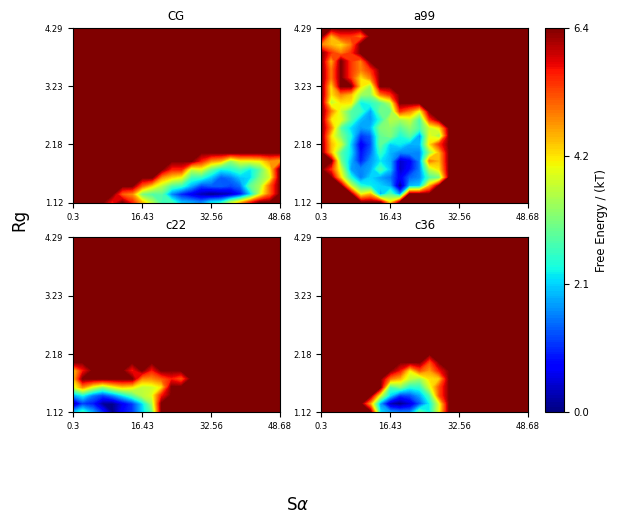

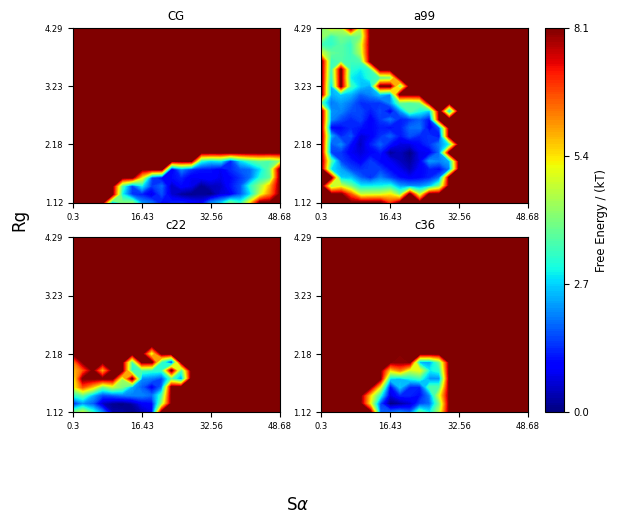

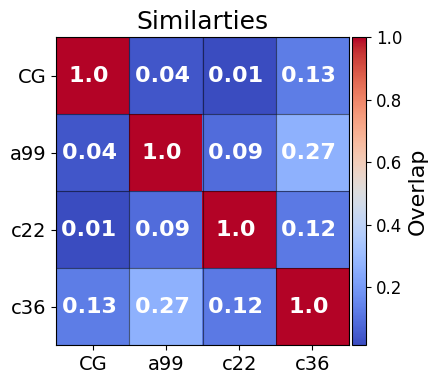

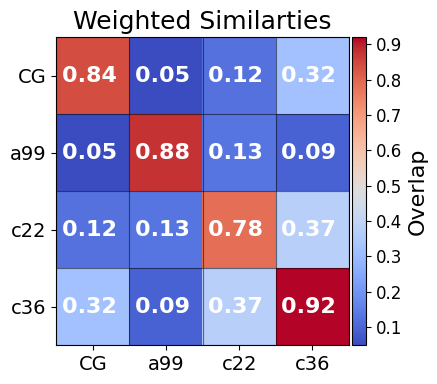

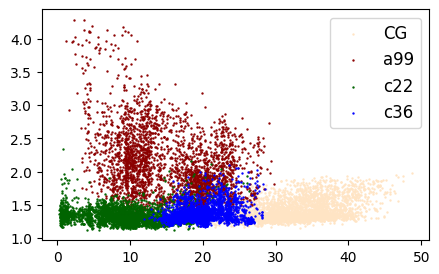

In [57]:
rg_sa = [np.stack([i, j]).T for i, j in zip([sa_cg, sa_disp, sa_c22, sa_c36m], [rg_cg, rg_disp, rg_c22, rg_c36m])]



subplots_fes2d(rg_sa, 2, 2, labels, bins=22, xlabel=r'S$\alpha$', ylabel='Rg',figsize=(6, 6))

subplots_fes2d(rg_sa, 2, 2, labels, bins=22, xlabel=r'S$\alpha$', ylabel='Rg',figsize=(6, 6),
               weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m])


# subplots_fes2d(rg_sa , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True, **fes2d_args)
# subplots_fes2d(rg_sa , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True,
#                weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m], **fes2d_args)

comp = DensityComparator(rg_sa, weights=[weights_cg, weights_disp, weights_c22, weights_c36m])
comp.estimate_kde()
comp.estimate_kde(weight=True)
comp.estimate_hist(bins=20)
comp.estimate_hist(bins=20, weight=True)
mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
#mat[i, j] = comp.compare('hists')
mat[i, j] = comp.compare('kdes')
mat += mat.T
mat[np.diag_indices(4)] = np.ones(4)
annotated_matrix_plot(mat, tick_labels=labels, title='Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',grid=True,
                      )

mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists', weight=True)
mat += mat.T
mat[np.diag_indices(4)] = np.array([comp.compare("kdes", pairs = np.array([[i, i]]), weight0=False, weight1=True) for i in range(4)]).flatten()

annotated_matrix_plot(mat, tick_labels=labels, title='Weighted Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',grid=True
                      )




fig, axes  = plt.subplots(1,1,figsize=(5, 3))
for color, label,  x in zip(['bisque', 'darkred', 'darkgreen', 'blue'], labels, rg_sa):
    axes.scatter(*x[:, :2].T, c=color, label=label, s=0.5)
axes.legend(bbox_to_anchor=[1,1], fontsize=12)

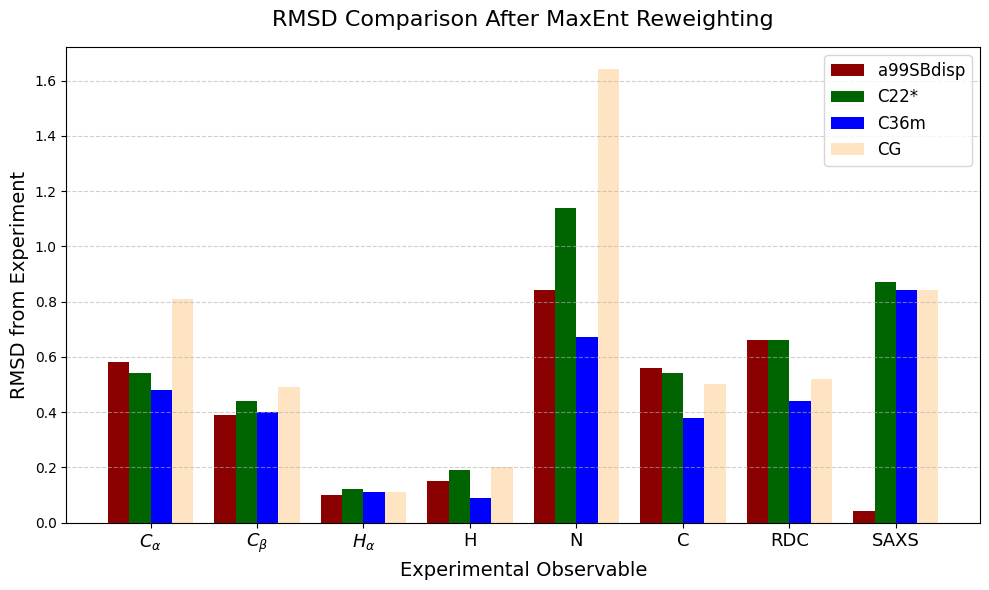

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Data
observables = [r'$C_{\alpha}$', r'$C_{\beta}$', r'$H_{\alpha}$', 'H', 'N', 'C', 'RDC', 'SAXS']
a99SBdisp = [0.58, 0.39, 0.10, 0.15, 0.84, 0.56, 0.66, 0.04]
c22star   = [0.54, 0.44, 0.12, 0.19, 1.14, 0.54, 0.66, 0.87]
c36m      = [0.48, 0.40, 0.11, 0.09, 0.67, 0.38, 0.44, 0.84]
CG        = [0.81, 0.49, 0.11, 0.20, 1.64, 0.50, 0.52, 0.84]

# Combine
ensembles = ['a99SBdisp', 'C22*', 'C36m', 'CG']
data = np.array([a99SBdisp, c22star, c36m, CG])

# Plot
x = np.arange(len(observables))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['darkred', 'darkgreen', 'blue','bisque']  

for i in range(len(ensembles)):
    ax.bar(x + i*width - width*1.5, data[i], width, label=ensembles[i], color=colors[i])

# Formatting
ax.set_ylabel('RMSD from Experiment', fontsize=14)
ax.set_xlabel('Experimental Observable', fontsize=14)
ax.set_title('RMSD Comparison After MaxEnt Reweighting', fontsize=16, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(observables, fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
